Original shape: (400, 4096)
Accuracy WITHOUT LDA: 0.92
Reduced shape after LDA: (300, 28)

===== RESULTS =====
KNN WITHOUT LDA: 0.92
KNN WITH LDA: 0.99

Dimensionality Reduction:
Before: 4096
After: 28


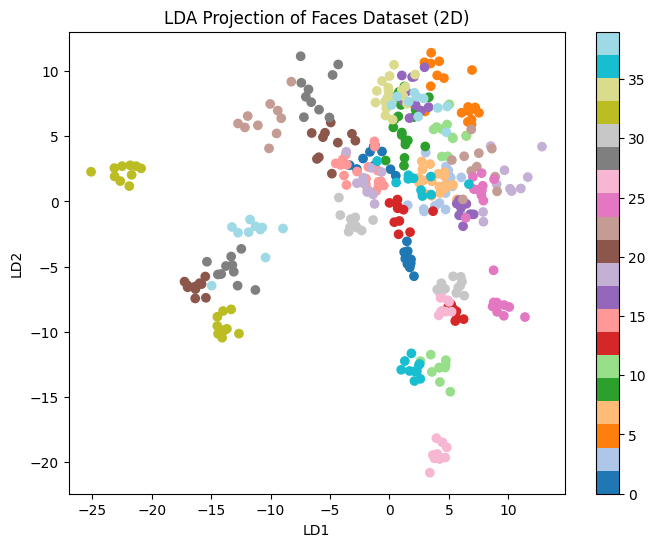

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


faces = fetch_olivetti_faces()

X = faces.data        # (400, 4096)
y = faces.target

print("Original shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)

y_pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

print("Accuracy WITHOUT LDA:", acc_raw)


lda = LinearDiscriminantAnalysis(n_components=28)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print("Reduced shape after LDA:", X_train_lda.shape)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_lda, y_train)

y_pred_lda = knn.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)


print("\n===== RESULTS =====")
print("KNN WITHOUT LDA:", acc_raw)
print("KNN WITH LDA:", acc_lda)

print("\nDimensionality Reduction:")
print("Before:", X.shape[1])
print("After:", X_train_lda.shape[1])

# Reduce to 2D for visualization
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_2d = lda_2d.fit_transform(X, y)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab20')

plt.title("LDA Projection of Faces Dataset (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")

plt.colorbar(scatter)
plt.show()
